# 1. Setup and Forecast Design

In [1]:
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from pandas.tseries.holiday import USFederalHolidayCalendar

In [2]:
current_dir = Path.cwd().resolve()
project_name = 'ride-hailing-demand-fleet-allocation'

if current_dir.name == project_name:
    project_root = current_dir
elif current_dir.name == 'notebooks' and current_dir.parent.name == project_name:
    project_root = current_dir.parent
else:
    project_root = current_dir / project_name

if not project_root.exists():
    raise FileNotFoundError(
        f'Project folder not found: {project_root}'
    )

database_path = project_root / 'data' / 'processed' / 'nyc_taxi.db'

print(f'Current directory: {current_dir}')
print(f'Project root     : {project_root}')
print(f'Database path    : {database_path}')

Current directory: D:\My Journey\Data Project\ride-hailing-demand-fleet-allocation\notebooks
Project root     : D:\My Journey\Data Project\ride-hailing-demand-fleet-allocation
Database path    : D:\My Journey\Data Project\ride-hailing-demand-fleet-allocation\data\processed\nyc_taxi.db


In [3]:
if not database_path.exists():
    raise FileNotFoundError(
        f'Database not found: {database_path}'
    )

con = duckdb.connect(str(database_path))

In [4]:
fact_trip_rows = con.execute("""
    SELECT COUNT(*)
    FROM fact_trip
""").fetchone()[0]

actionable_zones = con.execute("""
    SELECT COUNT(*)
    FROM dim_zone
    WHERE LocationID NOT IN (264, 265)
      AND Borough <> 'EWR'
""").fetchone()[0]

time_rows = con.execute("""
    SELECT COUNT(*)
    FROM dim_time
""").fetchone()[0]

print(f'Fact trip rows  : {fact_trip_rows:,}')
print(f'Actionable zones: {actionable_zones:,}')
print(f'Hourly time rows: {time_rows:,}')

Fact trip rows  : 239,426,737
Actionable zones: 262
Hourly time rows: 8,784


# 2. Build Hourly Demand Dataset

In [5]:
df_hourly_demand = con.execute("""
    WITH hourly_trips AS (
        SELECT
            trip.time_id,
            trip.PULocationID AS LocationID,
            COUNT(*) AS completed_trips
        FROM fact_trip AS trip
        JOIN dim_zone AS zone
            ON trip.PULocationID = zone.LocationID
        WHERE zone.LocationID NOT IN (264, 265)
          AND zone.Borough <> 'EWR'
        GROUP BY
            trip.time_id,
            trip.PULocationID
    )

    SELECT
        time.time_id,
        CAST(time.time_id AS DATE) AS demand_date,
        zone.LocationID,
        zone.Zone AS pickup_zone,
        zone.Borough AS pickup_borough,
        EXTRACT(HOUR FROM time.time_id) AS hour_of_day,
        ISODOW(time.time_id) AS day_of_week,
        EXTRACT(MONTH FROM time.time_id) AS month,
        CASE
            WHEN ISODOW(time.time_id) IN (6, 7) THEN 1
            ELSE 0
        END AS is_weekend,
        COALESCE(trip.completed_trips, 0) AS completed_trips
    FROM dim_time AS time
    CROSS JOIN dim_zone AS zone
    LEFT JOIN hourly_trips AS trip
        ON time.time_id = trip.time_id
        AND zone.LocationID = trip.LocationID
    WHERE zone.LocationID NOT IN (264, 265)
      AND zone.Borough <> 'EWR'
    ORDER BY
        time.time_id,
        zone.LocationID
""").df()

df_hourly_demand.head()

,time_id,demand_date,LocationID,pickup_zone,pickup_borough,hour_of_day,day_of_week,month,is_weekend,completed_trips
0,2024-01-01,2024-01-01,2,Jamaica Bay,Queens,0,1,1,0,0
1,2024-01-01,2024-01-01,3,Allerton/Pelham Gardens,Bronx,0,1,1,0,75
2,2024-01-01,2024-01-01,4,Alphabet City,Manhattan,0,1,1,0,266
3,2024-01-01,2024-01-01,5,Arden Heights,Staten Island,0,1,1,0,19
4,2024-01-01,2024-01-01,6,Arrochar/Fort Wadsworth,Staten Island,0,1,1,0,32


In [6]:
df_hourly_demand.info()

<class 'pandas.DataFrame'>
RangeIndex: 2301408 entries, 0 to 2301407
Data columns (total 10 columns):
 #   Column           Dtype         
---  ------           -----         
 0   time_id          datetime64[us]
 1   demand_date      datetime64[us]
 2   LocationID       int64         
 3   pickup_zone      str           
 4   pickup_borough   str           
 5   hour_of_day      int64         
 6   day_of_week      int64         
 7   month            int64         
 8   is_weekend       int32         
 9   completed_trips  int64         
dtypes: datetime64[us](2), int32(1), int64(5), str(2)
memory usage: 166.8 MB


In [7]:
holiday_calendar = USFederalHolidayCalendar()

holiday_series = holiday_calendar.holidays(
    start='2024-01-01',
    end='2025-12-31',
    return_name=True
)

df_holidays = (
    holiday_series
    .rename_axis('holiday_date')
    .reset_index(name='holiday_name')
)

df_hourly_demand['demand_date'] = pd.to_datetime(
    df_hourly_demand['demand_date']
)

df_hourly_demand['is_holiday'] = (
    df_hourly_demand['demand_date']
    .isin(df_holidays['holiday_date'])
    .astype('int8')
)

print(f'Holiday dates in 2024: {df_hourly_demand.loc[df_hourly_demand["is_holiday"] == 1, "demand_date"].nunique()}')
display(df_holidays[df_holidays['holiday_date'].dt.year == 2024])

Holiday dates in 2024: 11


,holiday_date,holiday_name
0,2024-01-01,New Year's Day
1,2024-01-15,"Birthday of Martin Luther King, Jr."
2,2024-02-19,Washington's Birthday
3,2024-05-27,Memorial Day
4,2024-06-19,Juneteenth National Independence Day
5,2024-07-04,Independence Day
6,2024-09-02,Labor Day
7,2024-10-14,Columbus Day
8,2024-11-11,Veterans Day
9,2024-11-28,Thanksgiving Day


In [8]:
df_hourly_demand['LocationID'] = df_hourly_demand['LocationID'].astype('int16')
df_hourly_demand['hour_of_day'] = df_hourly_demand['hour_of_day'].astype('int8')
df_hourly_demand['day_of_week'] = df_hourly_demand['day_of_week'].astype('int8')
df_hourly_demand['month'] = df_hourly_demand['month'].astype('int8')
df_hourly_demand['is_weekend'] = df_hourly_demand['is_weekend'].astype('int8')
df_hourly_demand['completed_trips'] = df_hourly_demand['completed_trips'].astype('int32')
df_hourly_demand[['pickup_zone', 'pickup_borough']] = df_hourly_demand[['pickup_zone', 'pickup_borough']].astype('category')

In [9]:
memory_mb = df_hourly_demand.memory_usage(
    deep=True
).sum() / 1024**2

print(f'Dataset memory: {memory_mb:,.2f} MB')

Dataset memory: 65.86 MB


In [10]:
expected_rows = time_rows * actionable_zones
actual_rows = len(df_hourly_demand)

print(f'Expected rows : {expected_rows:,}')
print(f'Actual rows   : {actual_rows:,}')
print(f'Unique hours  : {df_hourly_demand["time_id"].nunique():,}')
print(f'Unique zones  : {df_hourly_demand["LocationID"].nunique():,}')
print(f'Zero rows     : {(df_hourly_demand["completed_trips"] == 0).sum():,}')
print(f'Missing values: {df_hourly_demand["completed_trips"].isna().sum():,}')

Expected rows : 2,301,408
Actual rows   : 2,301,408
Unique hours  : 8,784
Unique zones  : 262
Zero rows     : 91,481
Missing values: 0


In [11]:
expected_trip_total = con.execute("""
    SELECT COUNT(*)
    FROM fact_trip AS trip
    JOIN dim_zone AS zone
        ON trip.PULocationID = zone.LocationID
    WHERE zone.LocationID NOT IN (264, 265)
      AND zone.Borough <> 'EWR'
""").fetchone()[0]

hourly_trip_total = df_hourly_demand[
    'completed_trips'
].sum()

print(f'Expected trip total: {expected_trip_total:,}')
print(f'Hourly trip total  : {hourly_trip_total:,}')
print(f'Totals match       : {expected_trip_total == hourly_trip_total}')

Expected trip total: 239,417,292
Hourly trip total  : 239,417,292
Totals match       : True


# 3. Create Time-Based Data Split

In [12]:
validation_start = pd.Timestamp('2024-11-01')
test_start = pd.Timestamp('2024-12-01')
test_end = pd.Timestamp('2025-01-01')

print(f'Validation starts: {validation_start.date()}')
print(f'Test starts      : {test_start.date()}')
print(f'Test ends        : {test_end.date()}')

Validation starts: 2024-11-01
Test starts      : 2024-12-01
Test ends        : 2025-01-01


In [13]:
df_train = df_hourly_demand[
    df_hourly_demand['time_id'] < validation_start
].copy()

df_validation = df_hourly_demand[
    (df_hourly_demand['time_id'] >= validation_start)
    & (df_hourly_demand['time_id'] < test_start)
].copy()

df_test = df_hourly_demand[
    (df_hourly_demand['time_id'] >= test_start)
    & (df_hourly_demand['time_id'] < test_end)
].copy()

In [14]:
print(f'Train rows     : {len(df_train):,}')
print(f'Validation rows: {len(df_validation):,}')
print(f'Test rows      : {len(df_test):,}')

print(
    f'\nTrain range     : '
    f'{df_train["time_id"].min()} to '
    f'{df_train["time_id"].max()}'
)

print(
    f'Validation range: '
    f'{df_validation["time_id"].min()} to '
    f'{df_validation["time_id"].max()}'
)

print(
    f'Test range      : '
    f'{df_test["time_id"].min()} to '
    f'{df_test["time_id"].max()}'
)

Train rows     : 1,917,840
Validation rows: 188,640
Test rows      : 194,928

Train range     : 2024-01-01 00:00:00 to 2024-10-31 23:00:00
Validation range: 2024-11-01 00:00:00 to 2024-11-30 23:00:00
Test range      : 2024-12-01 00:00:00 to 2024-12-31 23:00:00


In [15]:
df_split_summary = pd.DataFrame({
    'split': ['Train', 'Validation', 'Test'],
    'number_of_rows': [
        len(df_train),
        len(df_validation),
        len(df_test)
    ],
    'total_completed_trips': [
        df_train['completed_trips'].sum(),
        df_validation['completed_trips'].sum(),
        df_test['completed_trips'].sum()
    ],
    'avg_trips_per_zone_hour': [
        df_train['completed_trips'].mean(),
        df_validation['completed_trips'].mean(),
        df_test['completed_trips'].mean()
    ],
    'zero_demand_pct': [
        (df_train['completed_trips'] == 0).mean() * 100,
        (df_validation['completed_trips'] == 0).mean() * 100,
        (df_test['completed_trips'] == 0).mean() * 100
    ]
})

df_split_summary.round(2)

,split,number_of_rows,total_completed_trips,avg_trips_per_zone_hour,zero_demand_pct
0,Train,1917840,198378204,103.44,3.95
1,Validation,188640,19974210,105.89,4.04
2,Test,194928,21064878,108.06,4.13


In [16]:
df_holiday_split = pd.DataFrame({
    'split': ['Train', 'Validation', 'Test'],
    'holiday_dates': [
        df_train.loc[df_train['is_holiday'] == 1, 'demand_date'].nunique(),
        df_validation.loc[df_validation['is_holiday'] == 1, 'demand_date'].nunique(),
        df_test.loc[df_test['is_holiday'] == 1, 'demand_date'].nunique()
    ]
})

df_holiday_split

,split,holiday_dates
0,Train,8
1,Validation,2
2,Test,1


# 4. Build Historical Baseline

In [17]:
df_regular_baseline_lookup = (
    df_train[df_train['is_holiday'] == 0]
    .groupby(
        ['LocationID', 'hour_of_day', 'day_of_week'],
        as_index=False
    )
    .agg(regular_prediction=('completed_trips', 'mean'))
)

df_holiday_baseline_lookup = (
    df_train[df_train['is_holiday'] == 1]
    .groupby(
        ['LocationID', 'hour_of_day'],
        as_index=False
    )
    .agg(holiday_prediction=('completed_trips', 'mean'))
)

print(f'Regular lookup rows: {len(df_regular_baseline_lookup):,}')
print(f'Holiday lookup rows: {len(df_holiday_baseline_lookup):,}')

Regular lookup rows: 44,016
Holiday lookup rows: 6,288


In [18]:
df_validation_baseline = (
    df_validation
    .merge(
        df_regular_baseline_lookup,
        on=['LocationID', 'hour_of_day', 'day_of_week'],
        how='left'
    )
    .merge(
        df_holiday_baseline_lookup,
        on=['LocationID', 'hour_of_day'],
        how='left'
    )
)

holiday_fallback = (
    df_validation_baseline['holiday_prediction']
    .fillna(df_validation_baseline['regular_prediction'])
)

df_validation_baseline['baseline_prediction'] = np.where(
    df_validation_baseline['is_holiday'] == 1,
    holiday_fallback,
    df_validation_baseline['regular_prediction']
)

print(f'Validation rows      : {len(df_validation_baseline):,}')
print(f'Missing predictions  : {df_validation_baseline["baseline_prediction"].isna().sum():,}')
print(f'Negative predictions : {(df_validation_baseline["baseline_prediction"] < 0).sum():,}')

Validation rows      : 188,640
Missing predictions  : 0
Negative predictions : 0


# 5. Prepare Modeling Features

In [19]:
df_zone_avg = (
    df_train.groupby('LocationID', as_index=False)
    .agg(zone_avg_trips=('completed_trips', 'mean'))
)

df_zone_hour_avg = (
    df_train.groupby(['LocationID', 'hour_of_day'], as_index=False)
    .agg(zone_hour_avg_trips=('completed_trips', 'mean'))
)

df_zone_day_avg = (
    df_train.groupby(['LocationID', 'day_of_week'], as_index=False)
    .agg(zone_day_avg_trips=('completed_trips', 'mean'))
)

print(f'Zone lookup     : {len(df_zone_avg):,}')
print(f'Zone-hour lookup: {len(df_zone_hour_avg):,}')
print(f'Zone-day lookup : {len(df_zone_day_avg):,}')

Zone lookup     : 262
Zone-hour lookup: 6,288
Zone-day lookup : 1,834


In [20]:
base_columns = [
    'time_id',
    'LocationID',
    'hour_of_day',
    'day_of_week',
    'month',
    'is_weekend',
    'is_holiday',
    'completed_trips'
]

df_feature_data = pd.concat(
    [
        df_train[base_columns],
        df_validation[base_columns]
    ],
    ignore_index=True
)

df_feature_data = (
    df_feature_data
    .merge(df_zone_avg, on='LocationID', how='left')
    .merge(
        df_zone_hour_avg,
        on=['LocationID', 'hour_of_day'],
        how='left'
    )
    .merge(
        df_zone_day_avg,
        on=['LocationID', 'day_of_week'],
        how='left'
    )
    .merge(
        df_regular_baseline_lookup,
        on=['LocationID', 'hour_of_day', 'day_of_week'],
        how='left'
    )
    .merge(
        df_holiday_baseline_lookup,
        on=['LocationID', 'hour_of_day'],
        how='left'
    )
)

holiday_fallback = (
    df_feature_data['holiday_prediction']
    .fillna(df_feature_data['regular_prediction'])
)

df_feature_data['baseline_prediction'] = np.where(
    df_feature_data['is_holiday'] == 1,
    holiday_fallback,
    df_feature_data['regular_prediction']
)

df_feature_data['days_since_start'] = (
    df_feature_data['time_id'] - pd.Timestamp('2024-01-01')
).dt.days.astype('int16')

df_train_features = df_feature_data[
    df_feature_data['time_id'] < validation_start
].copy()

df_validation_features = df_feature_data[
    df_feature_data['time_id'] >= validation_start
].copy()

del df_feature_data, holiday_fallback

In [21]:
feature_columns = [
    'zone_avg_trips',
    'zone_hour_avg_trips',
    'zone_day_avg_trips',
    'baseline_prediction',
    'hour_of_day',
    'day_of_week',
    'month',
    'is_weekend',
    'is_holiday',
    'days_since_start'
]

target_column = 'completed_trips'

train_missing = df_train_features[feature_columns].isna().sum().sum()
validation_missing = df_validation_features[feature_columns].isna().sum().sum()

print(f'Train feature rows     : {len(df_train_features):,}')
print(f'Validation feature rows: {len(df_validation_features):,}')
print(f'Train missing values   : {train_missing:,}')
print(f'Validation missing     : {validation_missing:,}')

Train feature rows     : 1,917,840
Validation feature rows: 188,640
Train missing values   : 0
Validation missing     : 0


# 6. Train Candidate Models

In [22]:
X_train = df_train_features[feature_columns].astype('float32')
y_train = df_train_features[target_column].astype('float32')

X_validation = df_validation_features[feature_columns].astype('float32')
y_validation = df_validation_features[target_column].astype('float32')

print(f'Train      : X {X_train.shape}, y {y_train.shape}')
print(f'Validation : X {X_validation.shape}, y {y_validation.shape}')

Train      : X (1917840, 10), y (1917840,)
Validation : X (188640, 10), y (188640,)


In [23]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_prediction_raw = linear_model.predict(X_validation)
negative_linear_predictions = (linear_prediction_raw < 0).sum()
linear_validation_prediction = np.clip(linear_prediction_raw, 0, None)

print(f'Negative predictions before clipping: {negative_linear_predictions:,}')

Negative predictions before clipping: 15,627


In [24]:
boosting_model = HistGradientBoostingRegressor(
    loss='poisson',
    max_iter=150,
    learning_rate=0.08,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

boosting_model.fit(X_train, y_train)
boosting_validation_prediction = np.clip(boosting_model.predict(X_validation), 0, None)

In [25]:
df_validation_predictions = df_validation_features[
    ['time_id', 'LocationID', 'completed_trips', 'baseline_prediction']
].copy()

df_validation_predictions['linear_prediction'] = linear_validation_prediction
df_validation_predictions['boosting_prediction'] = boosting_validation_prediction

prediction_columns = [
    'baseline_prediction',
    'linear_prediction',
    'boosting_prediction'
]

missing_predictions = df_validation_predictions[prediction_columns].isna().sum().sum()
negative_predictions = (df_validation_predictions[prediction_columns] < 0).sum().sum()

models_passed = (
    len(df_validation_predictions) == len(df_validation)
    and missing_predictions == 0
    and negative_predictions == 0
)

print(f'Prediction rows     : {len(df_validation_predictions):,}')
print(f'Missing predictions : {missing_predictions:,}')
print(f'Negative predictions: {negative_predictions:,}')

Prediction rows     : 188,640
Missing predictions : 0
Negative predictions: 0


# 7. Evaluate and Select Model

## a. Validation model comparison

In [26]:
def calculate_wape(actual, prediction):
    return np.abs(actual - prediction).sum() / actual.sum() * 100

def calculate_mape_nonzero(actual, prediction):
    mask = actual > 0
    return np.abs((actual[mask] - prediction[mask]) / actual[mask]).mean() * 100

def calculate_bias(actual, prediction):
    return (prediction - actual).sum() / actual.sum() * 100

In [27]:
model_predictions = {
    'Holiday-Aware Historical Baseline': 'baseline_prediction',
    'Linear Regression': 'linear_prediction',
    'HistGradientBoosting': 'boosting_prediction'
}

actual_validation = df_validation_predictions['completed_trips'].to_numpy()
evaluation_rows = []

for model_name, prediction_column in model_predictions.items():
    prediction = df_validation_predictions[prediction_column].to_numpy()

    evaluation_rows.append({
        'model': model_name,
        'WAPE (%)': calculate_wape(actual_validation, prediction),
        'MAE': mean_absolute_error(actual_validation, prediction),
        'MAPE nonzero (%)': calculate_mape_nonzero(actual_validation, prediction),
        'Bias (%)': calculate_bias(actual_validation, prediction)
    })

df_validation_evaluation = (
    pd.DataFrame(evaluation_rows)
    .sort_values('WAPE (%)')
    .reset_index(drop=True)
)

df_validation_evaluation.round(2)

,model,WAPE (%),MAE,MAPE nonzero (%),Bias (%)
0,Holiday-Aware Historical Baseline,15.29,16.19,24.14,-1.71
1,HistGradientBoosting,16.61,17.59,27.76,4.15
2,Linear Regression,18.37,19.46,28.42,-4.43


Selected model : Holiday-Aware Historical Baseline
Validation WAPE: 15.29%


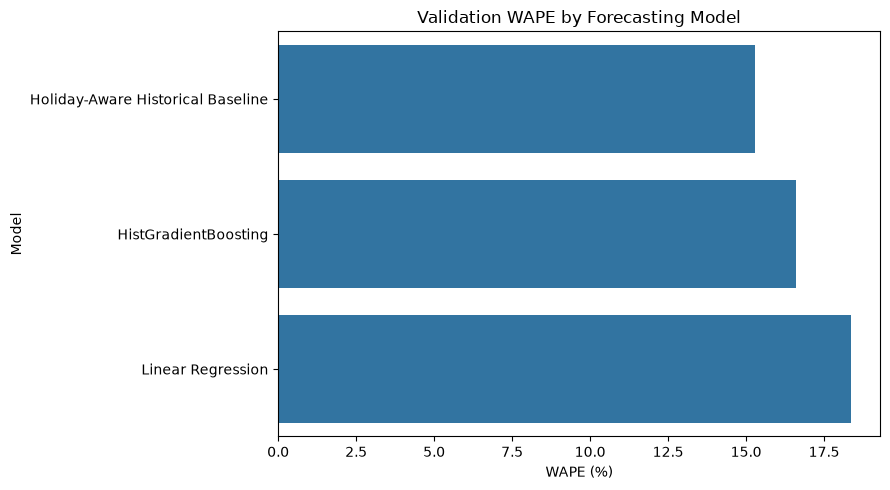

In [28]:
best_model_name = df_validation_evaluation.loc[0, 'model']
best_validation_wape = df_validation_evaluation.loc[0, 'WAPE (%)']

print(f'Selected model : {best_model_name}')
print(f'Validation WAPE: {best_validation_wape:.2f}%')

plt.figure(figsize=(9, 5))
sns.barplot(data=df_validation_evaluation, x='WAPE (%)', y='model')
plt.title('Validation WAPE by Forecasting Model')
plt.xlabel('WAPE (%)')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

## b. Final test evaluation

In [29]:
lookup_columns = [
    'LocationID',
    'hour_of_day',
    'day_of_week',
    'is_holiday',
    'completed_trips'
]

df_train_validation = pd.concat(
    [
        df_train[lookup_columns],
        df_validation[lookup_columns]
    ],
    ignore_index=True
)

df_final_regular_lookup = (
    df_train_validation[df_train_validation['is_holiday'] == 0]
    .groupby(
        ['LocationID', 'hour_of_day', 'day_of_week'],
        as_index=False
    )
    .agg(regular_prediction=('completed_trips', 'mean'))
)

df_final_holiday_lookup = (
    df_train_validation[df_train_validation['is_holiday'] == 1]
    .groupby(
        ['LocationID', 'hour_of_day'],
        as_index=False
    )
    .agg(holiday_prediction=('completed_trips', 'mean'))
)

print(f'Train-validation rows: {len(df_train_validation):,}')
print(f'Regular lookup rows  : {len(df_final_regular_lookup):,}')
print(f'Holiday lookup rows  : {len(df_final_holiday_lookup):,}')

del df_train_validation

Train-validation rows: 2,106,480
Regular lookup rows  : 44,016
Holiday lookup rows  : 6,288


In [30]:
df_test_predictions = (
    df_test
    .merge(
        df_final_regular_lookup,
        on=['LocationID', 'hour_of_day', 'day_of_week'],
        how='left'
    )
    .merge(
        df_final_holiday_lookup,
        on=['LocationID', 'hour_of_day'],
        how='left'
    )
)

holiday_fallback = (
    df_test_predictions['holiday_prediction']
    .fillna(df_test_predictions['regular_prediction'])
)

df_test_predictions['forecast_prediction'] = np.where(
    df_test_predictions['is_holiday'] == 1,
    holiday_fallback,
    df_test_predictions['regular_prediction']
)

df_test_predictions['forecast_prediction'] = np.clip(
    df_test_predictions['forecast_prediction'],
    0,
    None
)

print(f'Test prediction rows : {len(df_test_predictions):,}')
print(f'Missing predictions  : {df_test_predictions["forecast_prediction"].isna().sum():,}')
print(f'Negative predictions : {(df_test_predictions["forecast_prediction"] < 0).sum():,}')

Test prediction rows : 194,928
Missing predictions  : 0
Negative predictions : 0


In [31]:
test_actual = df_test_predictions['completed_trips'].to_numpy()
test_prediction = df_test_predictions['forecast_prediction'].to_numpy()

df_test_evaluation = pd.DataFrame({
    'model': [best_model_name],
    'WAPE (%)': [calculate_wape(test_actual, test_prediction)],
    'MAE': [mean_absolute_error(test_actual, test_prediction)],
    'MAPE nonzero (%)': [
        calculate_mape_nonzero(test_actual, test_prediction)
    ],
    'Bias (%)': [calculate_bias(test_actual, test_prediction)]
})

## c. Test error analysis

In [32]:
df_test_error = df_test_predictions.copy()
df_test_error['absolute_error'] = abs(df_test_error['completed_trips'] - df_test_error['forecast_prediction'])
df_test_error['signed_error'] = df_test_error['forecast_prediction'] - df_test_error['completed_trips']

df_daily_test_error = (
    df_test_error.groupby('demand_date', as_index=False)
    .agg(
        actual_trips=('completed_trips', 'sum'),
        predicted_trips=('forecast_prediction', 'sum'),
        absolute_error=('absolute_error', 'sum'),
        signed_error=('signed_error', 'sum')
    )
)

df_daily_test_error['WAPE (%)'] = df_daily_test_error['absolute_error'] / df_daily_test_error['actual_trips'] * 100
df_daily_test_error['Bias (%)'] = df_daily_test_error['signed_error'] / df_daily_test_error['actual_trips'] * 100

df_daily_test_error.sort_values(
    'WAPE (%)',
    ascending=False
).head(10).round({
    'predicted_trips': 2,
    'absolute_error': 2,
    'signed_error': 2,
    'WAPE (%)': 2,
    'Bias (%)': 2
})

,demand_date,actual_trips,predicted_trips,absolute_error,signed_error,WAPE (%),Bias (%)
30,2024-12-31,700066,583564.38,303775.33,-116501.62,43.39,-16.64
25,2024-12-26,493447,658149.46,205774.07,164702.46,41.70,33.38
24,2024-12-25,506645,567282.20,184578.20,60637.20,36.43,11.97
23,2024-12-24,616897,583564.38,213581.08,-33332.62,34.62,-5.40
26,2024-12-27,556671,715964.35,182776.52,159293.35,32.83,28.62
27,2024-12-28,619891,767556.02,188155.23,147665.02,30.35,23.82
28,2024-12-29,545334,659573.77,147019.09,114239.77,26.96,20.95
22,2024-12-23,608648,559779.54,138037.93,-48868.46,22.68,-8.03
29,2024-12-30,523025,559779.54,116112.05,36754.54,22.20,7.03
10,2024-12-11,741695,621994.06,144290.64,-119700.94,19.45,-16.14


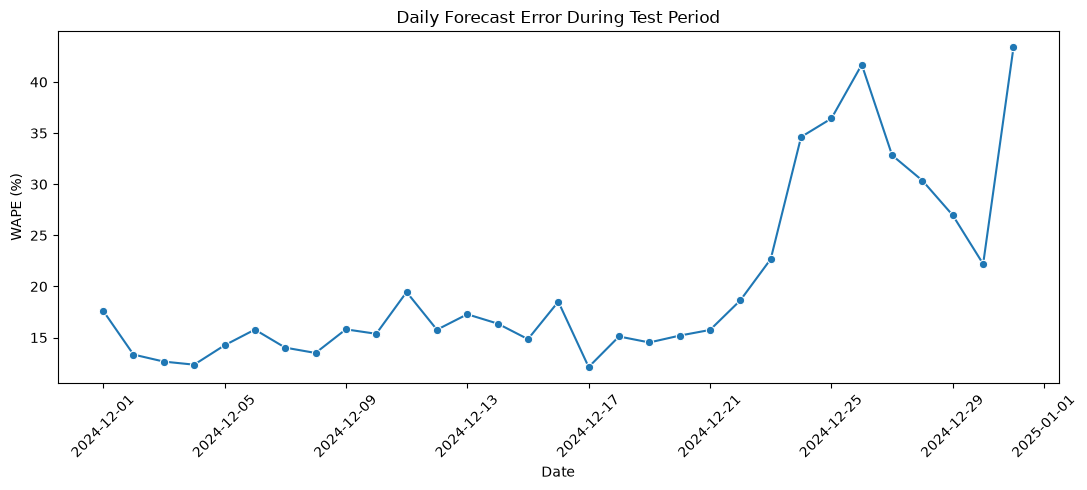

In [33]:
plt.figure(figsize=(11, 5))
sns.lineplot(data=df_daily_test_error, x='demand_date', y='WAPE (%)', marker='o')
plt.title('Daily Forecast Error During Test Period')
plt.xlabel('Date')
plt.ylabel('WAPE (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
df_zone_volume = (
    pd.concat([
        df_train[['LocationID', 'completed_trips']],
        df_validation[['LocationID', 'completed_trips']]
    ])
    .groupby('LocationID', as_index=False)
    .agg(avg_hourly_trips=('completed_trips', 'mean'))
)

df_zone_volume['volume_tier'] = pd.qcut(
    df_zone_volume['avg_hourly_trips'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

df_test_tier = df_test_predictions.merge(
    df_zone_volume[['LocationID', 'volume_tier']],
    on='LocationID',
    how='left'
)

tier_results = []

for tier in ['Low', 'Medium', 'High']:
    tier_data = df_test_tier[df_test_tier['volume_tier'] == tier]
    actual = tier_data['completed_trips'].to_numpy()
    prediction = tier_data['forecast_prediction'].to_numpy()

    tier_results.append({
        'volume_tier': tier,
        'WAPE (%)': calculate_wape(actual, prediction),
        'MAE': mean_absolute_error(actual, prediction),
        'Bias (%)': calculate_bias(actual, prediction)
    })

df_test_tier_evaluation = pd.DataFrame(tier_results)
df_test_tier_evaluation.round(2)

,volume_tier,WAPE (%),MAE,Bias (%)
0,Low,22.98,5.62,-8.52
1,Medium,17.73,15.65,-7.66
2,High,20.00,42.49,-3.47


# 8. Generate Future Forecast

In [35]:
df_full_regular_lookup = (
    df_hourly_demand[df_hourly_demand['is_holiday'] == 0]
    .groupby(
        ['LocationID', 'hour_of_day', 'day_of_week'],
        as_index=False
    )
    .agg(regular_prediction=('completed_trips', 'mean'))
)

df_full_holiday_lookup = (
    df_hourly_demand[df_hourly_demand['is_holiday'] == 1]
    .groupby(
        ['LocationID', 'hour_of_day'],
        as_index=False
    )
    .agg(holiday_prediction=('completed_trips', 'mean'))
)

print(f'Full regular lookup: {len(df_full_regular_lookup):,}')
print(f'Full holiday lookup: {len(df_full_holiday_lookup):,}')

Full regular lookup: 44,016
Full holiday lookup: 6,288


In [36]:
forecast_start = pd.Timestamp('2025-01-01')
forecast_end = pd.Timestamp('2025-01-08')

df_future_time = pd.DataFrame({
    'time_id': pd.date_range(
        start=forecast_start,
        end=forecast_end,
        freq='h',
        inclusive='left'
    )
})

df_future_time['demand_date'] = df_future_time['time_id'].dt.normalize()
df_future_time['hour_of_day'] = df_future_time['time_id'].dt.hour.astype('int8')
df_future_time['day_of_week'] = (df_future_time['time_id'].dt.dayofweek + 1).astype('int8')
df_future_time['is_weekend'] = df_future_time['day_of_week'].isin([6, 7]).astype('int8')
df_future_time['is_holiday'] = df_future_time['demand_date'].isin(
    df_holidays['holiday_date']
).astype('int8')

holiday_name_map = df_holidays.set_index(
    'holiday_date'
)['holiday_name']

df_future_time['holiday_name'] = (
    df_future_time['demand_date']
    .map(holiday_name_map)
    .fillna('Non-holiday')
)

df_future_time.head() 

,time_id,demand_date,hour_of_day,day_of_week,is_weekend,is_holiday,holiday_name
0,2025-01-01 00:00:00,2025-01-01,0,3,0,1,New Year's Day
1,2025-01-01 01:00:00,2025-01-01,1,3,0,1,New Year's Day
2,2025-01-01 02:00:00,2025-01-01,2,3,0,1,New Year's Day
3,2025-01-01 03:00:00,2025-01-01,3,3,0,1,New Year's Day
4,2025-01-01 04:00:00,2025-01-01,4,3,0,1,New Year's Day


In [37]:
df_forecast_zones = (
    df_hourly_demand[
        ['LocationID', 'pickup_zone', 'pickup_borough']
    ]
    .drop_duplicates()
    .merge(
        df_zone_volume[['LocationID', 'volume_tier']],
        on='LocationID',
        how='left'
    )
    .reset_index(drop=True)
)

df_future_forecast = (
    df_future_time
    .merge(df_forecast_zones, how='cross')
    .merge(
        df_full_regular_lookup,
        on=['LocationID', 'hour_of_day', 'day_of_week'],
        how='left'
    )
    .merge(
        df_full_holiday_lookup,
        on=['LocationID', 'hour_of_day'],
        how='left'
    )
)

holiday_fallback = (
    df_future_forecast['holiday_prediction']
    .fillna(df_future_forecast['regular_prediction'])
)

df_future_forecast['forecast_completed_trips'] = np.where(
    df_future_forecast['is_holiday'] == 1,
    holiday_fallback,
    df_future_forecast['regular_prediction']
)

df_future_forecast['forecast_completed_trips'] = np.clip(
    df_future_forecast['forecast_completed_trips'],
    0,
    None
)

df_future_forecast.head()

,time_id,demand_date,hour_of_day,day_of_week,is_weekend,is_holiday,holiday_name,LocationID,pickup_zone,pickup_borough,volume_tier,regular_prediction,holiday_prediction,forecast_completed_trips
0,2025-01-01,2025-01-01,0,3,0,1,New Year's Day,2,Jamaica Bay,Queens,Low,0.00,0.000000,0.000000
1,2025-01-01,2025-01-01,0,3,0,1,New Year's Day,3,Allerton/Pelham Gardens,Bronx,Medium,23.34,40.181818,40.181818
2,2025-01-01,2025-01-01,0,3,0,1,New Year's Day,4,Alphabet City,Manhattan,Medium,56.78,102.272727,102.272727
3,2025-01-01,2025-01-01,0,3,0,1,New Year's Day,5,Arden Heights,Staten Island,Low,2.08,7.363636,7.363636
4,2025-01-01,2025-01-01,0,3,0,1,New Year's Day,6,Arrochar/Fort Wadsworth,Staten Island,Low,5.54,11.818182,11.818182


In [38]:
df_forecast_output = df_future_forecast[
    [
        'time_id',
        'demand_date',
        'LocationID',
        'pickup_zone',
        'pickup_borough',
        'hour_of_day',
        'day_of_week',
        'is_weekend',
        'is_holiday',
        'holiday_name',
        'volume_tier',
        'forecast_completed_trips'
    ]
].rename(columns={
    'time_id': 'forecast_time',
    'demand_date': 'forecast_date'
})

df_forecast_output['model'] = best_model_name

text_columns = [
    'pickup_zone',
    'pickup_borough',
    'holiday_name',
    'volume_tier'
]
df_forecast_output[text_columns] = (
    df_forecast_output[text_columns].astype(str)
)

print(f'Forecast rows     : {len(df_forecast_output):,}')
print(f'Holiday rows      : {df_forecast_output["is_holiday"].sum():,}')
print(f'Missing tier values: {df_forecast_output["volume_tier"].isna().sum():,}')
df_forecast_output.head()

Forecast rows     : 44,016
Holiday rows      : 6,288
Missing tier values: 0


,forecast_time,forecast_date,LocationID,pickup_zone,pickup_borough,hour_of_day,day_of_week,is_weekend,is_holiday,holiday_name,volume_tier,forecast_completed_trips,model
0,2025-01-01,2025-01-01,2,Jamaica Bay,Queens,0,3,0,1,New Year's Day,Low,0.000000,Holiday-Aware Historical Baseline
1,2025-01-01,2025-01-01,3,Allerton/Pelham Gardens,Bronx,0,3,0,1,New Year's Day,Medium,40.181818,Holiday-Aware Historical Baseline
2,2025-01-01,2025-01-01,4,Alphabet City,Manhattan,0,3,0,1,New Year's Day,Medium,102.272727,Holiday-Aware Historical Baseline
3,2025-01-01,2025-01-01,5,Arden Heights,Staten Island,0,3,0,1,New Year's Day,Low,7.363636,Holiday-Aware Historical Baseline
4,2025-01-01,2025-01-01,6,Arrochar/Fort Wadsworth,Staten Island,0,3,0,1,New Year's Day,Low,11.818182,Holiday-Aware Historical Baseline


In [39]:
expected_forecast_rows = len(df_future_time) * actionable_zones
expected_holiday_rows = (
    df_future_time['is_holiday'].sum() * actionable_zones
)

check_forecast_rows = (
    len(df_forecast_output) == expected_forecast_rows
)
check_holiday_rows = (
    df_forecast_output['is_holiday'].sum()
    == expected_holiday_rows
)
check_new_year = (
    df_forecast_output.loc[
        df_forecast_output['forecast_time'].dt.date
        == pd.Timestamp('2025-01-01').date(),
        'is_holiday'
    ].eq(1).all()
)
check_missing = (
    df_forecast_output['forecast_completed_trips']
    .isna().sum() == 0
)
check_negative = (
    df_forecast_output['forecast_completed_trips']
    .lt(0).sum() == 0
)
check_duplicates = (
    df_forecast_output
    .duplicated(['forecast_time', 'LocationID'])
    .sum() == 0
)

check_tiers = (
    df_forecast_output['volume_tier'].isna().sum() == 0
)

forecast_validation_passed = all([
    check_forecast_rows,
    check_holiday_rows,
    check_new_year,
    check_missing,
    check_negative,
    check_duplicates,
    check_tiers
])

print(f'Forecast rows valid : {check_forecast_rows}')
print(f'Holiday rows valid  : {check_holiday_rows}')
print(f'New Year recognized : {check_new_year}')
print(f'No missing forecast : {check_missing}')
print(f'No negative forecast: {check_negative}')
print(f'No duplicate rows   : {check_duplicates}')

Forecast rows valid : True
Holiday rows valid  : True
New Year recognized : True
No missing forecast : True
No negative forecast: True
No duplicate rows   : True


In [40]:
df_future_daily = (
    df_future_forecast
    .groupby('demand_date', as_index=False)
    .agg(
        forecast_completed_trips=(
            'forecast_completed_trips',
            'sum'
        )
    )
    .rename(columns={'demand_date': 'forecast_date'})
)

df_future_daily.round({
    'forecast_completed_trips': 2
})

,forecast_date,forecast_completed_trips
0,2025-01-01,561769.73
1,2025-01-02,659625.74
2,2025-01-03,718829.48
3,2025-01-04,769328.79
4,2025-01-05,659669.06
5,2025-01-06,564708.43
6,2025-01-07,589658.06


# 9. Save Forecast Output

In [41]:
df_validation_metrics = df_validation_evaluation.copy()
df_validation_metrics.insert(
    0,
    'evaluation_period',
    'Validation'
)

df_test_metrics = df_test_evaluation.copy()
df_test_metrics.insert(
    0,
    'evaluation_period',
    'Test'
)

df_model_evaluation = pd.concat(
    [df_validation_metrics, df_test_metrics],
    ignore_index=True
)

print(f'Forecast output rows : {len(df_forecast_output):,}')
print(f'Model evaluation rows: {len(df_model_evaluation):,}')
print(f'Tier evaluation rows : {len(df_test_tier_evaluation):,}')

Forecast output rows : 44,016
Model evaluation rows: 4
Tier evaluation rows : 3


In [42]:
con.execute("""
    CREATE OR REPLACE TABLE forecast_output AS
    SELECT * FROM df_forecast_output
""")

con.execute("""
    CREATE OR REPLACE TABLE forecast_model_evaluation AS
    SELECT * FROM df_model_evaluation
""")

con.execute("""
    CREATE OR REPLACE TABLE forecast_test_tier_evaluation AS
    SELECT * FROM df_test_tier_evaluation
""")

# 10. Final Validation and Close Connection

In [43]:
df_saved_forecast_check = con.execute("""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT forecast_time) AS unique_hours,
        COUNT(DISTINCT LocationID) AS unique_zones,
        MIN(forecast_time) AS min_forecast_time,
        MAX(forecast_time) AS max_forecast_time,

        COUNT(*) FILTER (
            WHERE forecast_completed_trips IS NULL
        ) AS missing_predictions,

        COUNT(*) FILTER (
            WHERE forecast_completed_trips < 0
        ) AS negative_predictions,

        COUNT(*) FILTER (
            WHERE is_holiday = 1
        ) AS holiday_rows,

        COUNT(*) FILTER (
            WHERE CAST(forecast_time AS DATE) = DATE '2025-01-01'
              AND is_holiday <> 1
        ) AS invalid_new_year_rows,

        COUNT(DISTINCT model) AS number_of_models
    FROM forecast_output
""").df()

df_saved_forecast_check

,total_rows,unique_hours,unique_zones,min_forecast_time,max_forecast_time,missing_predictions,negative_predictions,holiday_rows,invalid_new_year_rows,number_of_models
0,44016,168,262,2025-01-01,2025-01-07 23:00:00,0,0,6288,0,1


In [44]:
saved_evaluation_rows = con.execute("""
    SELECT COUNT(*) FROM forecast_model_evaluation
""").fetchone()[0]

saved_tier_rows = con.execute("""
    SELECT COUNT(*) FROM forecast_test_tier_evaluation
""").fetchone()[0]

saved_model = con.execute("""
    SELECT DISTINCT model FROM forecast_output
""").fetchone()[0]

print(f'Model evaluation rows: {saved_evaluation_rows:,}')
print(f'Tier evaluation rows : {saved_tier_rows:,}')
print(f'Forecast model       : {saved_model}')

Model evaluation rows: 4
Tier evaluation rows : 3
Forecast model       : Holiday-Aware Historical Baseline


In [45]:
saved_check = df_saved_forecast_check.iloc[0]
con.close()